**Task 1 - Data loading and exploration**

Load the csv file using pandas

In [1]:
import pandas as pd
df=pd.read_csv('Housing.csv')

Display first 10 rows

In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Checking how many rows and columns are there

In [5]:
df.shape
print("rows=",df.shape[0])
print("columns=",df.shape[1])

rows= 545
columns= 13


Target - Price
Features -  area,bedrooms,bathrooms,stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus

Checking for missing values in each column

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Task 2 - Data cleaning**

Handle missing values – As there are no missing values, there is no need of handling it.

Checking whether if there are any duplicate rows

In [9]:
print("Dupilcate rows=",int(df.duplicated().sum()))

Dupilcate rows= 0


Replacing 'yes' with 1 and 'no' with 0

In [14]:
data=df.copy()
data=data.replace({"yes":1,"no":0})
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


Replacing 'unfurnished' with 0, 'semi-furnished' with 1 and 'furnished' with 2

In [15]:
data['furnishingstatus']=data['furnishingstatus'].replace({'unfurnished':0,'semi-furnished':1,'furnished':2})
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


As all columns are meaningful for predicting price, we are keeping them all.

**Task 3 - Model Building**

Splitting the data into training and test sets (80/20)

In [18]:
from sklearn.model_selection import train_test_split 
x=data.drop(columns=["price"]) #features
y=data["price"] #target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Training set size: (436, 12)
Testing set size: (109, 12)


Training a Linear Regression Model

In [20]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
lr_preds=lr_model.predict(x_test)
print("Linear Regression model training and prediction completed!") 

Linear Regression model training and prediction completed


Evaluating using MAE, RMSE and R² score

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)
print("--- Linear Regression Report Card ---")
print("MAE  (Average Error): ₹",int(lr_mae))
print("RMSE (Penalty Error): ₹",int(lr_rmse))
print("R² Score (Accuracy) :", round(lr_r2, 4))

--- Linear Regression Report Card ---
MAE  (Average Error): ₹ 979679
RMSE (Penalty Error): ₹ 1331071
R² Score (Accuracy) : 0.6495


Training a second model - Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(x_train,y_train)
rf_preds=rf_model.predict(x_test)
print("Random Forest model training and prediction completed!")

Random Forest model training and prediction completed!


Evaluating Random Forest model

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)
print("--- Random Forest Report Card ---")
print("MAE  (Average Error): ₹",int(rf_mae))
print("RMSE (Penalty Error): ₹",int(rf_rmse))
print("R² Score (Accuracy) :", round(rf_r2, 4))

--- Random Forest Report Card ---
MAE  (Average Error): ₹ 1024081
RMSE (Penalty Error): ₹ 1398901
R² Score (Accuracy) : 0.6128


Comparing both models

As the R² value is more for the linear regression model (0.6495) than the random forest model (0.6128), the linear regression model is best suited for predicting the price.

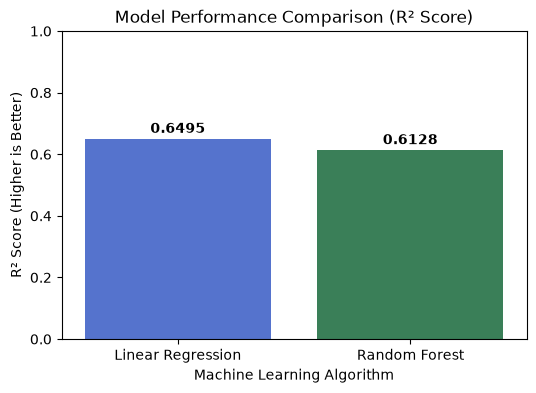

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ["Linear Regression", "Random Forest"]
scores = [lr_r2, rf_r2]

plt.figure(figsize=(6, 4))
sns.barplot(x=model_names, y=scores, hue=model_names, palette=["royalblue", "seagreen"], legend=False)

plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("R² Score (Higher is Better)")  
plt.ylim(0,1.0)

for index, value in enumerate(scores):
    plt.text(index, value + 0.02, round(value,4), ha="center", fontweight="bold")

plt.show()

**Task 4 – Visualisation**

Chart 1: Histogram showing the distribution of house prices

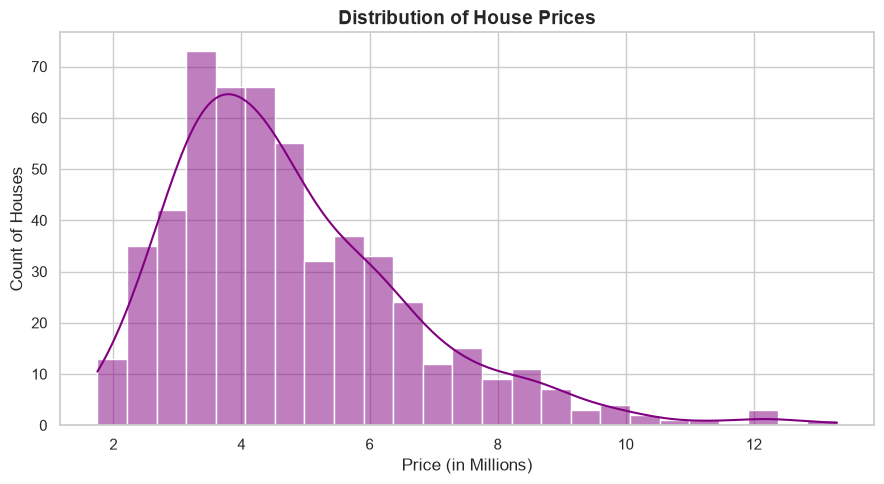

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

#using simple column division to make it clean
sns.histplot(data["price"] / 1000000, kde=True, color="purple", bins=25)

plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price (in Millions)", fontsize=12)
plt.ylabel("Count of Houses", fontsize=12)

plt.tight_layout()
plt.show()

Chart 2:  Correlation heatmap showing which features relate most strongly to price

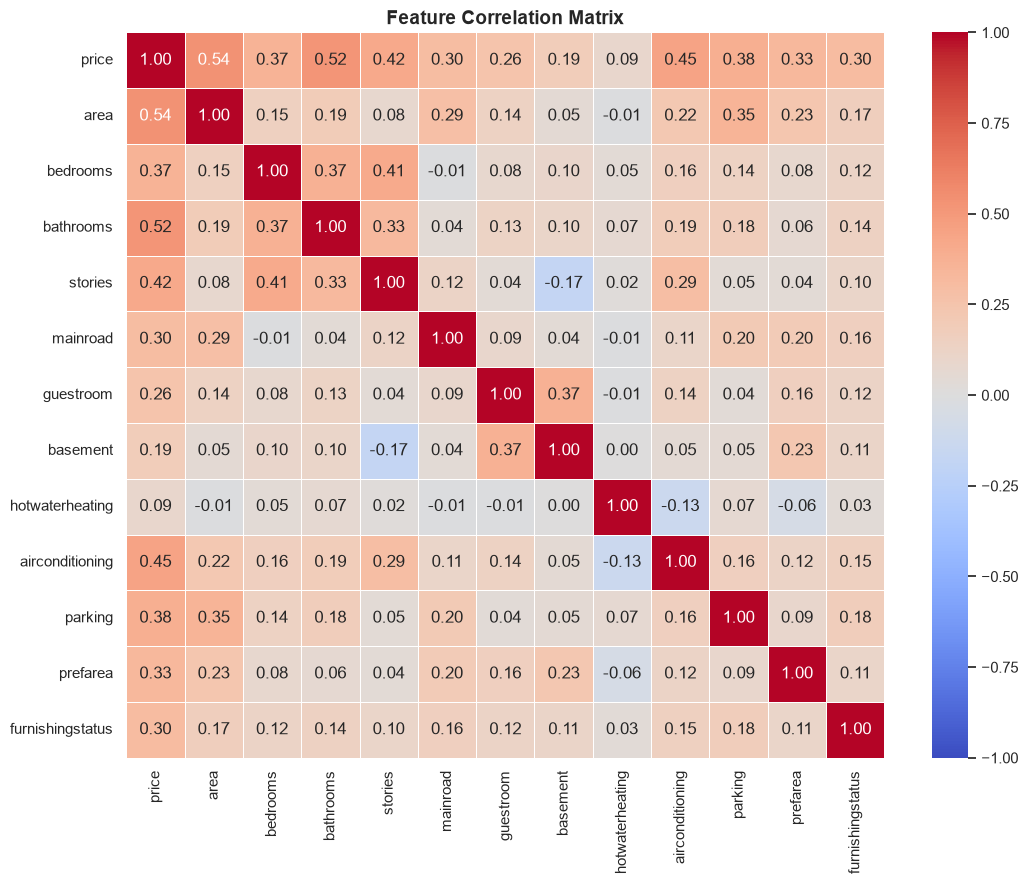

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 9))

# Calculate how all features relate to each other
correlation_matrix = data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Chart 3: Actual vs Predicted price

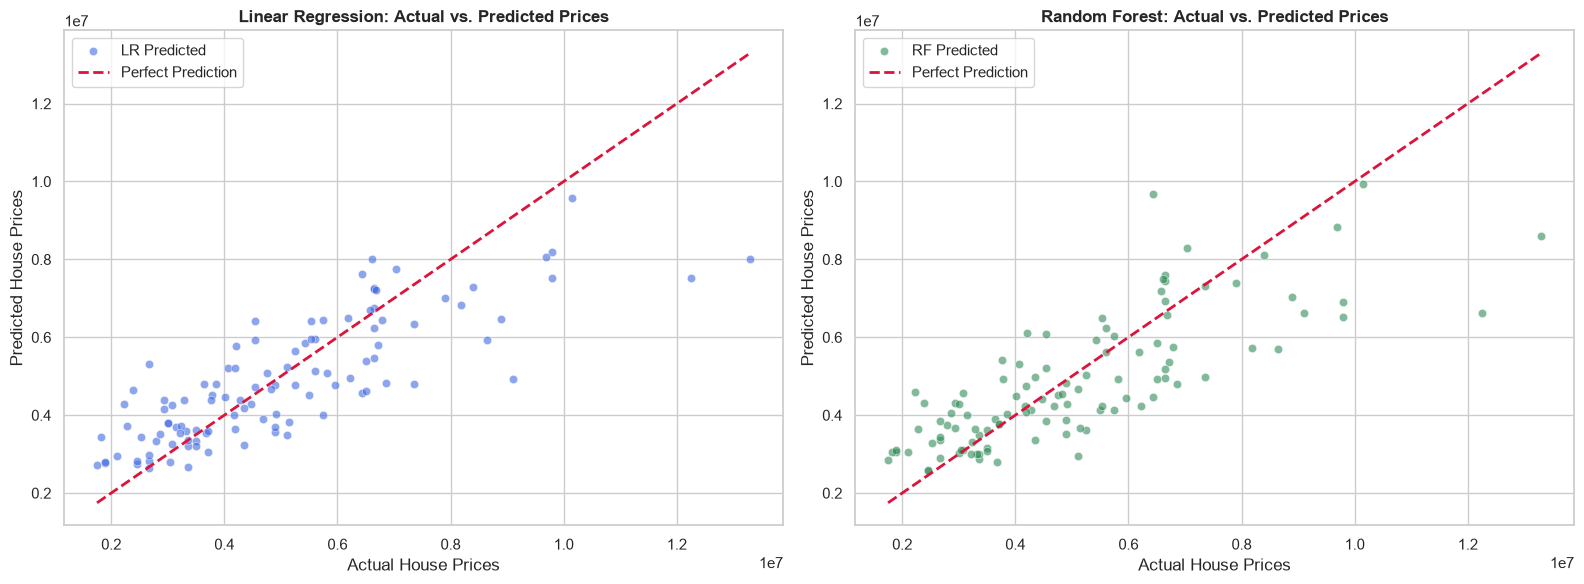

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Linear Regression Scatter Plot
sns.scatterplot(
    ax=axes[0], x=y_test, y=lr_preds, color="royalblue", alpha=0.6, label="LR Predicted"
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction",
)
axes[0].set_title("Linear Regression: Actual vs. Predicted Prices", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Actual House Prices")
axes[0].set_ylabel("Predicted House Prices")
axes[0].legend()

# Graph 2: Random Forest Scatter Plot
sns.scatterplot(
    ax=axes[1], x=y_test, y=rf_preds, color="seagreen", alpha=0.6, label="RF Predicted"
)

axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction",
)
axes[1].set_title("Random Forest: Actual vs. Predicted Prices", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Actual House Prices")
axes[1].set_ylabel("Predicted House Prices")
axes[1].legend()

plt.tight_layout()
plt.show()


We can see that in the linear regression model the dots are less scattered, i.e., the prediction is more accurate than in the random forest model, in which the dots are more scattered. 

**Task 5 - Insights and Summary**

From the analysis, I came to the conclusion that the **area** and the number of **bathrooms** are features that influence the price the most, followed by the presence of **air conditioning**, while hot water heating affects it the least. In plain terms, our winning Linear Regression model was moderately accurate, successfully capturing about 65% of the true pricing trends while keeping its predictions within a predictable error margin. What surprised me most was that the simple Linear Regression model actually beat the complex Random Forest model, proving that advanced algorithms are not always better for smaller, straight-line datasets. Based on these findings, I recommend that real estate businesses should focus their investment and marketing budgets on properties with large layouts and multiple bathrooms, as these specific features bring in the highest and most reliable profits.